# 🚗 Driver Behavior Anomaly Detection
## Notebook 03 — Sliding Window Segmentation (Step 4)

### Why Windows?
Neural networks need **fixed-size inputs**.  
A single sensor reading tells us very little — but a **5-second window** shows the pattern.

### Strategy
- **Window size:** 50 samples ≈ 5 seconds (at ~10 Hz)
- **Overlap:** 50% (stride = 25) — creates more training data, avoids missing events
- **Label:** majority vote of all timestep labels in the window

```
Raw signal:   ████████████████████████████████
Window 1:     [════════════════════]
Window 2:              [════════════════════]
Window 3:                       [════════════════════]
```

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

OUTPUT_DIR   = "outputs"
CLASS_NAMES  = ["NORMAL", "AGGRESSIVE", "SLOW"]
CLASS_COLORS = {"NORMAL": "#2ecc71", "AGGRESSIVE": "#e74c3c", "SLOW": "#3498db"}
SENSOR_COLS  = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
DERIVED_COLS = ['jerk_x','jerk_y','jerk_z','lateral_qforce','speed_variance']
ALL_FEATURES = SENSOR_COLS + DERIVED_COLS

WINDOW_SIZE  = 50
STRIDE       = 25

# Load processed data from Notebook 02
df = pd.read_csv(f"{OUTPUT_DIR}/processed_data.csv")
print(f"✅ Loaded processed data: {df.shape}")

✅ Loaded processed data: (3084, 16)


### Create sliding windows

In [2]:
def create_windows(df, feature_cols, label_col='label',
                   window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Slide a window across the time series.
    
    Returns:
        X  →  shape (n_windows, window_size, n_features)
        y  →  shape (n_windows,)   — majority-vote label
    """
    values = df[feature_cols].values.astype(np.float32)
    labels = df[label_col].values.astype(np.int32)
    
    X_list, y_list = [], []
    
    for start in range(0, len(values) - window_size + 1, stride):
        end = start + window_size
        
        window_X = values[start:end]           # shape: (window_size, n_features)
        window_y = labels[start:end]
        
        # Assign the most common label in this window
        majority_label = Counter(window_y).most_common(1)[0][0]
        
        X_list.append(window_X)
        y_list.append(majority_label)
    
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


X, y = create_windows(df, ALL_FEATURES)

print(f"Window size : {WINDOW_SIZE} samples")
print(f"Stride      : {STRIDE} samples  (50% overlap)")
print(f"\nX shape     : {X.shape}   ← (n_windows × timesteps × features)")
print(f"y shape     : {y.shape}")

Window size : 50 samples
Stride      : 25 samples  (50% overlap)

X shape     : (122, 50, 11)   ← (n_windows × timesteps × features)
y shape     : (122,)


### Class distribution after windowing

In [3]:
print("Window label distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y == i)
    pct   = 100 * count / len(y)
    bar   = '█' * int(pct / 2)
    print(f"  {name:12s} [{i}] : {count:4d} windows  ({pct:.1f}%)  {bar}")

Window label distribution:
  NORMAL       [0] :   40 windows  (32.8%)  ████████████████
  AGGRESSIVE   [1] :   32 windows  (26.2%)  █████████████
  SLOW         [2] :   50 windows  (41.0%)  ████████████████████


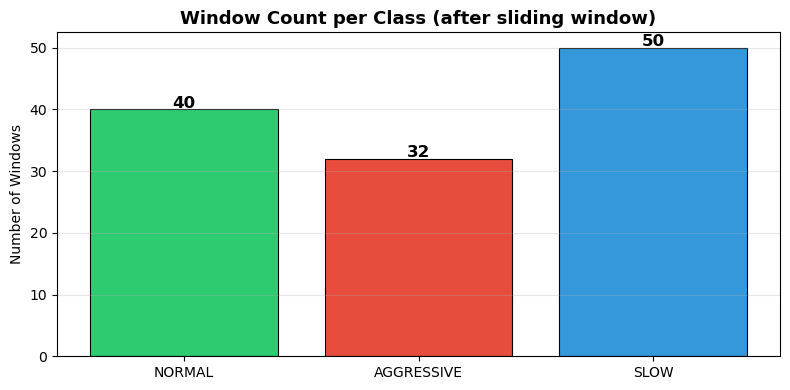

In [4]:
# Visualise window distribution as bar chart
counts = [np.sum(y == i) for i in range(len(CLASS_NAMES))]
colors = [CLASS_COLORS[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.8)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(cnt), ha='center', fontsize=12, fontweight='bold')

ax.set_title("Window Count per Class (after sliding window)", fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Windows")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_window_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Visualise sample windows per class

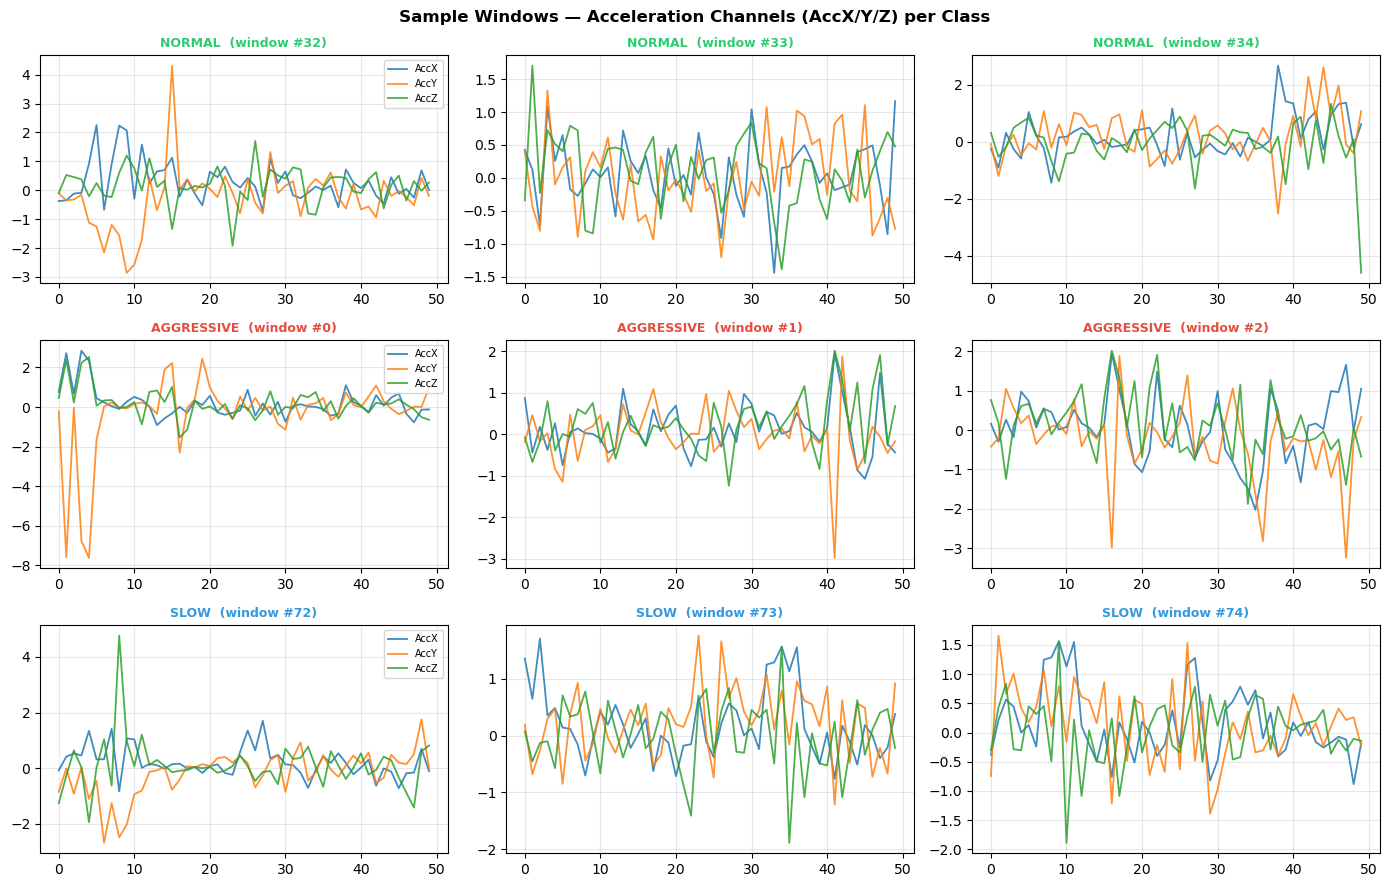

In [5]:
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(14, 9), sharey=False)
acc_idx = [ALL_FEATURES.index(f) for f in ['AccX','AccY','AccZ']]

for row, (cls_id, cls_name) in enumerate(enumerate(CLASS_NAMES)):
    color  = CLASS_COLORS[cls_name]
    idxs   = np.where(y == cls_id)[0][:3]   # first 3 windows of this class
    
    for col, win_idx in enumerate(idxs):
        ax     = axes[row][col]
        window = X[win_idx]                  # shape: (50, 11)
        
        for i, feat in zip(acc_idx, ['AccX','AccY','AccZ']):
            ax.plot(window[:, i], linewidth=1.3, alpha=0.85, label=feat)
        
        ax.set_title(f"{cls_name}  (window #{win_idx})",
                     fontsize=9, color=color, fontweight='bold')
        ax.grid(alpha=0.3)
        if col == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle("Sample Windows — Acceleration Channels (AccX/Y/Z) per Class",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_sample_windows.png", dpi=150, bbox_inches='tight')
plt.show()

### Save windows

In [6]:
np.save(f"{OUTPUT_DIR}/X_windows.npy", X)
np.save(f"{OUTPUT_DIR}/y_windows.npy", y)

print("✅ Windows saved:")
print(f"   X → outputs/X_windows.npy   shape {X.shape}")
print(f"   y → outputs/y_windows.npy   shape {y.shape}")

✅ Windows saved:
   X → outputs/X_windows.npy   shape (122, 50, 11)
   y → outputs/y_windows.npy   shape (122,)


### ✅ Windowing Complete

**What we did:**
- Created **122 windows** of 50 timesteps each (5 seconds of sensor data)
- 50% overlap ensures we capture events at window boundaries
- Each window labelled by majority vote → single class prediction target

**Shape:** `X = (122, 50, 11)` → 122 windows × 50 timesteps × 11 sensor channels

**Next:** `04_Balance_Normalize.ipynb`